### Prerequisites:

Before we dive into the implementation, we have to install some prerequisistes:

 - we use [pandas](https://pandas.pydata.org/docs/) to easily load and format our data
 - we use the [crepes](https://github.com/henrikbostrom/crepes) library together with [scikit-learn](https://scikit-learn.org/stable/api/index.html) to implement our conformal base classifier
 - we use Qwen's open source LLM [Qwen 2.5-3B](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct) for prompting

 - All experiments will be performed on the [Go Emotions Dataset](https://huggingface.co/datasets/google-research-datasets/go_emotions).

In [1]:
%%capture
# install dependecies:
!pip install numpy matplotlib seaborn torch pandas scikit-learn crepes transformers accelerate tqdm

### Data processing

In [2]:
from datasets import load_dataset

train_data = load_dataset("go_emotions", "simplified", split="train")
test_data = load_dataset("go_emotions", "simplified", split="test")

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 43410 examples
Test set size: 5427 examples


In [3]:
# filter to keep only single-label examples:
def is_single_label(example):
    return len(example["labels"]) == 1

train_data = train_data.filter(is_single_label)
test_data = test_data.filter(is_single_label)

# flatten the label from list to scalar:
def flatten_label(example):
    example["label"] = example["labels"][0]
    return example

train_data = train_data.map(flatten_label)
test_data = test_data.map(flatten_label)

print(f"Train set size: {len(train_data)} examples")
print(f"Test set size: {len(test_data)} examples")

Train set size: 36308 examples
Test set size: 4590 examples


In [4]:
# get the label names:
label_names = train_data.features['labels'].feature.names

# create a mapping from index to label:
index2label = {i: name for i, name in enumerate(label_names)}

In [5]:
# convert datasets to dataframes:
train_df = train_data.to_pandas()
test_df = test_data.to_pandas()

train_df.sample()

,text,labels,id,label
5993,How old are you?,[27],edknpqk,27


In [6]:
from sklearn.model_selection import train_test_split

# sample 2k training examples stratified by label:
train_df, _ = train_test_split(
    train_df, stratify=train_df["label"], train_size=2000, random_state=42
)

# sample 1k test examples stratified by label:
test_df, _ = train_test_split(
    test_df, stratify=test_df["label"], train_size=1000, random_state=42
)

# create the development set:
train_df, dev_df = train_test_split(
    train_df, stratify=train_df["label"], test_size=0.2, shuffle=True, random_state=42
)

print(f"Train subset size: {len(train_df)} examples")
print(f"Dev subset size: {len(dev_df)} examples")
print(f"Test subset size: {len(test_df)} examples")

Train subset size: 1600 examples
Dev subset size: 400 examples
Test subset size: 1000 examples


We use the `label` associated with each news `text` as the target category to predict:

In [7]:
# map numeric labels to string labels:
train_df['label'] = train_df['label'].map(index2label)
dev_df['label'] = dev_df['label'].map(index2label)
test_df['label'] = test_df['label'].map(index2label)

In [8]:
# select input and label from data:
X_train = train_df['text'].to_numpy()
y_train = train_df['label'].to_numpy()

X_dev = dev_df['text'].to_numpy()
y_dev = dev_df['label'].to_numpy()

X_test = test_df['text'].to_numpy()
y_test = test_df['label'].to_numpy()

classes = set(y_train)
print('Classes: ', len(classes))

Classes:  28


### Dense Embeddings for Similarity (MiniLM)

We import the MiniLM model from `sentence-transformers` and use it to create dense vector embeddings for our texts. Unlike TF-IDF, MiniLM produces dense representations directly, so no sparse-to-dense conversion is needed.

We define a utility function (`phi`) that encodes a list of texts into embeddings using the model.

In [9]:
from sentence_transformers import SentenceTransformer

# load MiniLM model
minilm = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# define embedding function
phi = lambda x: minilm.encode(x, convert_to_numpy=True)

# test embedding shape
phi(X_train[:2]).shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(2, 384)

Now let's create a list of unique labels (`id2label`) from the training labels `y_train`. We then build a dictionary (`label2id`) that maps each label to a unique ID using enumeration. Finally, we display the label-to-ID mapping by printing `label2id`.

In [10]:
import numpy as np

# create label to one-hot and reverse dictionaries:
id2label = np.unique(y_train)
label2id = {l:i for i, l in enumerate(id2label)}

# show label-id mapping:
label2id

{'admiration': 0,
 'amusement': 1,
 'anger': 2,
 'annoyance': 3,
 'approval': 4,
 'caring': 5,
 'confusion': 6,
 'curiosity': 7,
 'desire': 8,
 'disappointment': 9,
 'disapproval': 10,
 'disgust': 11,
 'embarrassment': 12,
 'excitement': 13,
 'fear': 14,
 'gratitude': 15,
 'grief': 16,
 'joy': 17,
 'love': 18,
 'nervousness': 19,
 'neutral': 20,
 'optimism': 21,
 'pride': 22,
 'realization': 23,
 'relief': 24,
 'remorse': 25,
 'sadness': 26,
 'surprise': 27}

In [11]:
from sklearn.metrics import pairwise_distances

def get_fixed_k_examples(text, k=2):
    """
    Return exactly k training examples with highest cosine similarity to `text`,
    selected globally across all classes.
    Returns list of (text, label, similarity) tuples sorted by descending similarity.
    """
    embeddings = phi([text] + X_train.tolist())
    similarity = (1. - pairwise_distances(embeddings[:1], embeddings[1:], metric="cosine"))[0]
    top_k_idx = np.argsort(similarity)[::-1][:k]
    return [(X_train[i], y_train[i], similarity[i]) for i in top_k_idx]

In [12]:
# verify: show the 8 globally most similar training examples to the first test sample:
n = 8
t = X_test[0]
examples = get_fixed_k_examples(t, k=n)
print(f"Query: {t!r}\n")
for i, (text, label, sim) in enumerate(examples):
    print(f"{i+1}. [{label}] (sim={sim:.3f}) {text!r}")

Query: 'In what ways has [NAME] out-coached [NAME]? I see this all the time and yet never any examples.'

1. [anger] (sim=0.442) 'What the fuck is [NAME] doing in the background'
2. [neutral] (sim=0.426) 'With [NAME] impersonating [NAME] after getting arrested yesterday, this makes it pretty clear who gave [NAME] that phrase.'
3. [neutral] (sim=0.411) 'Used to be the same with [NAME]'
4. [neutral] (sim=0.406) 'is [NAME] playing?'
5. [amusement] (sim=0.393) '[NAME] keeps getting set to get a rebound [NAME]'
6. [approval] (sim=0.388) "Well he is saying the right sort of things. I'm glad [NAME] won but I'd like to see [NAME] come back well."
7. [confusion] (sim=0.388) '[NAME] has never said he wanted to build the team around [NAME]. Not sure why people are spreading this rumour.'
8. [fear] (sim=0.388) 'That [NAME] missed layup is haunting me right now.'


### Instantiate Qwen

In order to be able to use huggingface's Qwen 2.5 models, we first need to log in to huggingface (you can request access to the model [here](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct)).

In [13]:
# import getpass
# from huggingface_hub import login
# login(getpass.getpass('Enter your huggingface API-key:'))

In this tutorial we will use the standard huggingface text-generation pipeline (compressed to 16 bit floating point weights) for the instruction tuned 3B parameter version of Qwen 2.5.

In [14]:
import transformers
import torch

# create llm pipeline:
llm = transformers.pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-3B-Instruct",
    model_kwargs={"torch_dtype": torch.bfloat16},
    device_map="auto",
    trust_remote_code=True
)

# Get special tokens for later:
bos_token_id = llm.tokenizer.bos_token_id
eos_token_id = llm.tokenizer.eos_token_id
pad_token_id = llm.tokenizer.pad_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

### Results Handling Helper

In [15]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import json

def save_results(y_true, y_pred, classes, filename="results.json"):
    """
    Save classification metrics (report, accuracy, confusion matrix) to JSON.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted labels
        classes: List of all class labels (keeps consistent ordering)
        filename: Output JSON filename
    """
    report = classification_report(
        y_true, y_pred, labels=classes, zero_division=0, output_dict=True
    )
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    results = {
        "classification_report": report,
        "accuracy": accuracy,
        "confusion_matrix": cm.tolist(),
        "labels": classes 
    }

    with open(filename, "w") as f:
        json.dump(results, f, indent=2)

    print(f"Results saved to: '{filename}'")

In [16]:
import json
import numpy as np

def save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="prompt_lengths.json"):
    """
    Save prompt, input, shots section lengths, and number of shots to a JSON file, 
    including summary statistics.

    Args:
        prompt_lengths: List of total prompt token counts.
        input_lengths: List of input (test text) token counts.
        shots_lengths: List of few-shot section token counts.
        num_shots: List of number of few-shot examples per prompt.
        filename: Output JSON filename.
    """
    stats = {
        "prompt_lengths": {
            "mean": float(np.mean(prompt_lengths)),
            "min": int(np.min(prompt_lengths)),
            "max": int(np.max(prompt_lengths)),
            "std": float(np.std(prompt_lengths)),
            "values": prompt_lengths
        },
        "input_lengths": {
            "mean": float(np.mean(input_lengths)),
            "min": int(np.min(input_lengths)),
            "max": int(np.max(input_lengths)),
            "std": float(np.std(input_lengths)),
            "values": input_lengths
        },
        "shots_lengths": {
            "mean": float(np.mean(shots_lengths)),
            "min": int(np.min(shots_lengths)),
            "max": int(np.max(shots_lengths)),
            "std": float(np.std(shots_lengths)),
            "values": shots_lengths
        },
        "num_shots": {
            "mean": float(np.mean(num_shots)),
            "min": int(np.min(num_shots)),
            "max": int(np.max(num_shots)),
            "std": float(np.std(num_shots)),
            "values": num_shots
        }
    }

    with open(filename, "w") as f:
        json.dump(stats, f, indent=2)

    print(f"Prompt length statistics saved to: '{filename}'")

### Few-shot learning with Most Similar Examples (Dense Embeddings / MiniLM)

Generate a prompt for classification using a given text and $n$ labeled examples.

In [17]:
def get_prompt(text, shots):
    replace_qm = lambda s: s.replace('"', "'")
    prompt = 'We classify user questions into topic categories based on their text. Here are some labelled examples:\n'
    for x,y in shots: prompt += f'\n"{replace_qm(x)}" => {y}'
    return {"role": "user", "content": f'{prompt}\n\nPlease predict the correct class for the following sample. Only provide the class label.\n\n"{replace_qm(text)}" => '}

shots_examples = get_fixed_k_examples(X_test[0], k=n)
shots = [(x, y) for x, y, _ in shots_examples]
prompt = get_prompt(X_test[0], shots)["content"]
print(prompt)

We classify user questions into topic categories based on their text. Here are some labelled examples:

"What the fuck is [NAME] doing in the background" => anger
"With [NAME] impersonating [NAME] after getting arrested yesterday, this makes it pretty clear who gave [NAME] that phrase." => neutral
"Used to be the same with [NAME]" => neutral
"is [NAME] playing?" => neutral
"[NAME] keeps getting set to get a rebound [NAME]" => amusement
"Well he is saying the right sort of things. I'm glad [NAME] won but I'd like to see [NAME] come back well." => approval
"[NAME] has never said he wanted to build the team around [NAME]. Not sure why people are spreading this rumour." => confusion
"That [NAME] missed layup is haunting me right now." => fear

Please predict the correct class for the following sample. Only provide the class label.

"In what ways has [NAME] out-coached [NAME]? I see this all the time and yet never any examples." => 


In [18]:
from tqdm import tqdm
import numpy as np

def few_shot_learning_batch(test, y_train, n=2):
    outputs        = []
    prompt_lengths = []
    input_lengths  = []
    shots_lengths  = []
    num_shots      = []

    for i, t in tqdm(enumerate(test), total=len(test)):
        shots_examples = get_fixed_k_examples(t, k=n)
        shots = [(x, y) for x, y, _ in shots_examples]
        num_shots.append(len(shots))
        prompt = get_prompt(t, shots)
        prompt_len  = len(llm.tokenizer(prompt["content"])["input_ids"])
        input_len   = len(llm.tokenizer(t)["input_ids"])
        shots_text  = "\n".join([x for x, _ in shots])
        shots_len   = len(llm.tokenizer(shots_text)["input_ids"])
        prompt_lengths.append(prompt_len)
        input_lengths.append(input_len)
        shots_lengths.append(shots_len)
        outputs.append(llm(
            [prompt],
            bos_token_id=bos_token_id,
            eos_token_id=eos_token_id,
            pad_token_id=pad_token_id,
            max_new_tokens=5,
            do_sample=False,
            temperature=None,
            top_p=None
        )[0]["generated_text"][-1]["content"])
    return outputs, prompt_lengths, input_lengths, shots_lengths, num_shots


predictions, prompt_lengths, input_lengths, shots_lengths, num_shots = few_shot_learning_batch(
    X_test, y_train, n=8
)

print(f"Average prompt length:        {np.mean(prompt_lengths):.1f} tokens")
print(f"Average input length:         {np.mean(input_lengths):.1f} tokens")
print(f"Average shots section length: {np.mean(shots_lengths):.1f} tokens")
print(f"Average num shots:            {np.mean(num_shots):.1f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Passing `generation_config` together with generation-related arguments=({'eos_token_id', 'pad_token_id', 'temperature', 'top_p', 'max_new_tokens', 'bos_token_id', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  0%|          | 1/1000 [00:01<22:56,  1.38s/it]

...

100%|█████████▉| 999/1000 [17:30<00:01,  1.04s/it]

Both `max_new_tokens` (=5) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


100%|██████████| 1000/1000 [17:31<00:00,  1.06s/it]

100%|██████████| 1000/1000 [17:31<00:00,  1.05s/it]

Average prompt length:        206.4 tokens
Average input length:         16.1 tokens
Average shots section length: 125.6 tokens
Average num shots:            8.0


In [19]:
predictions[:10]

['confusion',
 'optimism',
 'admiration',
 'disapproval',
 'anger',
 'admiration',
 'disapproval',
 'love',
 'sadness',
 'gratitude']

Classification Report:
                 precision    recall  f1-score   support

        relief       0.00      0.00      0.00         2
           joy       0.17      0.20      0.19        20
        desire       0.13      0.17      0.15        12
   nervousness       1.00      0.33      0.50         3
        caring       0.08      0.05      0.06        19
         pride       0.50      0.50      0.50         2
    excitement       0.21      0.33      0.26        12
       sadness       0.32      0.45      0.38        22
 embarrassment       0.14      0.20      0.17         5
     confusion       0.08      0.14      0.10        21
     gratitude       0.67      0.42      0.52        57
disappointment       0.06      0.16      0.09        19
         grief       0.00      0.00      0.00         0
       disgust       0.41      0.41      0.41        17
   realization       0.20      0.05      0.08        19
       neutral       0.54      0.21      0.30       350
          fear       0.

Text(0.5, 1.0, 'Confusion Matrix')

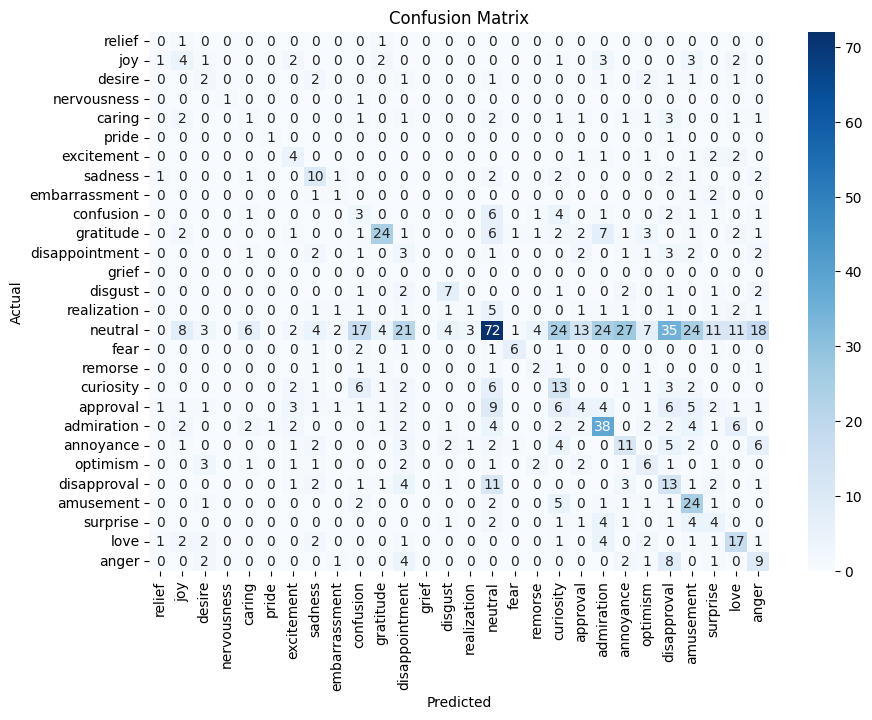

In [20]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Classification Report:\n", classification_report(y_test, predictions, labels=list(classes), zero_division=0))
print("Accuracy:", accuracy_score(y_test, predictions))

# Plot confusion matrix
cm = confusion_matrix(y_test, predictions, labels=list(classes))
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

In [21]:
save_results(y_test, predictions, list(classes), filename="/home/v25/ippa6201/cicle-evaluation/go-emotions/results/predictions/go-emotions-qwen-2.5-3b-fewshot-minilm-2.0k-samples-8-shots-fixed.json")

Results saved to: '/home/v25/ippa6201/cicle-evaluation/go-emotions/results/predictions/go-emotions-qwen-2.5-3b-fewshot-minilm-2.0k-samples-8-shots-fixed.json'


In [22]:
save_prompt_lengths(prompt_lengths, input_lengths, shots_lengths, num_shots, filename="/home/v25/ippa6201/cicle-evaluation/go-emotions/results/lengths/go-emotions-qwen-2.5-3b-fewshot-minilm-2.0k-samples-8-shots-fixed.json")

Prompt length statistics saved to: '/home/v25/ippa6201/cicle-evaluation/go-emotions/results/lengths/go-emotions-qwen-2.5-3b-fewshot-minilm-2.0k-samples-8-shots-fixed.json'
